In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import HistGradientBoostingRegressor
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_poisson_deviance, mean_absolute_error, mean_squared_error

In [7]:
df = pd.read_csv('data/processed_data_last_3.csv')

features = [
'diff_elo',
'diff_avg_goals_for', 
'diff_avg_goals_against',
'diff_avg_points', 
'diff_ranking',
'diff_fifa_points',
'ranking_local',
'ranking_away',
'change_local',
'change_away'
]

df_train = df[df["date"] < "2026-05-01"]
df_train = df_train.dropna(subset=features)

df_train = df_train[(df_train["date"] < "2024-01-01") ].copy()
X_train = df_train[features]
y_train = df_train["result"]
df_test = df[(df["date"] >= "2024-01-01") ].copy()
df_test = df[(df["date"] < "2026-05-01") ].copy()
X_test = df_test[features]
y_test = df_test["result"]
y_test

y_train_local = df_train["home_score"]  
y_train_away = df_train["away_score"]    
y_test_local = df_test["home_score"]    
y_test_away = df_test["away_score"]


model_goals_local = HistGradientBoostingRegressor(
    loss='poisson', 
    max_iter=100,  
    learning_rate=0.03,  
    max_depth=3,  
    min_samples_leaf=70,  
    random_state=45,
)

model_goals_away = HistGradientBoostingRegressor(
    loss='poisson', 
    max_iter=100,  
    learning_rate=0.03,  
    max_depth=3,  
    min_samples_leaf=70,  
    random_state=45,
)

model_goals_local.fit(X_train, y_train_local)
model_goals_away.fit(X_train, y_train_away)

,"loss loss: {'squared_error', 'absolute_error', 'gamma', 'poisson', 'quantile'}, default='squared_error'The loss function to use in the boosting process. Note that the""squared error"", ""gamma"" and ""poisson"" losses actually implement""half least squares loss"", ""half gamma deviance"" and ""half poissondeviance"" to simplify the computation of the gradient. Furthermore,""gamma"" and ""poisson"" losses internally use a log-link, ""gamma""requires ``y > 0`` and ""poisson"" requires ``y >= 0``.""quantile"" uses the pinball loss... versionchanged:: 0.23 Added option 'poisson'... versionchanged:: 1.1 Added option 'quantile'... versionchanged:: 1.3 Added option 'gamma'.",'poisson'
,"quantile quantile: float, default=NoneIf loss is ""quantile"", this parameter specifies which quantile to be estimatedand must be between 0 and 1.",None
,"learning_rate learning_rate: float, default=0.1The learning rate, also known as *shrinkage*. This is used as amultiplicative factor for the leaves values. Use ``1`` for noshrinkage.",0.03
,"max_iter max_iter: int, default=100The maximum number of iterations of the boosting process, i.e. themaximum number of trees.",100
,"max_leaf_nodes max_leaf_nodes: int or None, default=31The maximum number of leaves for each tree. Must be strictly greaterthan 1. If None, there is no maximum limit.",31
,"max_depth max_depth: int or None, default=NoneThe maximum depth of each tree. The depth of a tree is the number ofedges to go from the root to the deepest leaf.Depth isn't constrained by default.",3
,"min_samples_leaf min_samples_leaf: int, default=20The minimum number of samples per leaf. For small datasets with lessthan a few hundred samples, it is recommended to lower this valuesince only very shallow trees would be built.",70
,"l2_regularization l2_regularization: float, default=0The L2 regularization parameter penalizing leaves with small hessians.Use ``0`` for no regularization (default).",0.0
,"max_features max_features: float, default=1.0Proportion of randomly chosen features in each and every node split.This is a form of regularization, smaller values make the trees weakerlearners and might prevent overfitting.If interaction constraints from `interaction_cst` are present, only allowedfeatures are taken into account for the subsampling... versionadded:: 1.4",1.0
,"max_bins max_bins: int, default=255The maximum number of bins to use for non-missing values. Beforetraining, each feature of the input array `X` is binned intointeger-valued bins, which allows for a much faster training stage.Features with a small number of unique values may use less than``max_bins`` bins. In addition to the ``max_bins`` bins, one more binis always reserved for missing values. Must be no larger than 255.",255
,"categorical_features categorical_features: array-like of {bool, int, str} of shape (n_features) or shape (n_categorical_features,), default='from_dtype'Indicates the categorical features.- None : no feature will be considered categorical.- boolean array-like : boolean mask indicating categorical features.- integer array-like : integer indices indicating categorical features.- str array-like: names of categorical features (assuming the training data has feature names).- `""from_dtype""`: dataframe columns with dtype ""category"" are considered to be categorical features. The input must be an object exposing a ``__dataframe__`` method such as pandas or polars DataFrames to use this feature.For each categorical feature, there must be at most `max_bins` uniquecategories. Negative values for categorical features encoded as numericdtypes are treated as missing values. All categorical values areconverted to floating point numbers. This means that categorical valuesof 1.0 and 1 are treated as the same category.Read more in the :ref:`User Guide ` and:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_categorical.py`... versionadded:: 0.24.. versionchanged:: 1.2 Added support for feature names... versionchanged:: 1.4 Adde

<>:33: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
<>:33: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
C:\Users\TrendingPc\AppData\Local\Temp\ipykernel_18808\2413656170.py:33: SyntaxWarning: "\l" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\l"? A raw string is also an option.
  axes[0].set_title('Distribution of Validation Errors (Real Goals - $\lambda$)', fontsize=14)


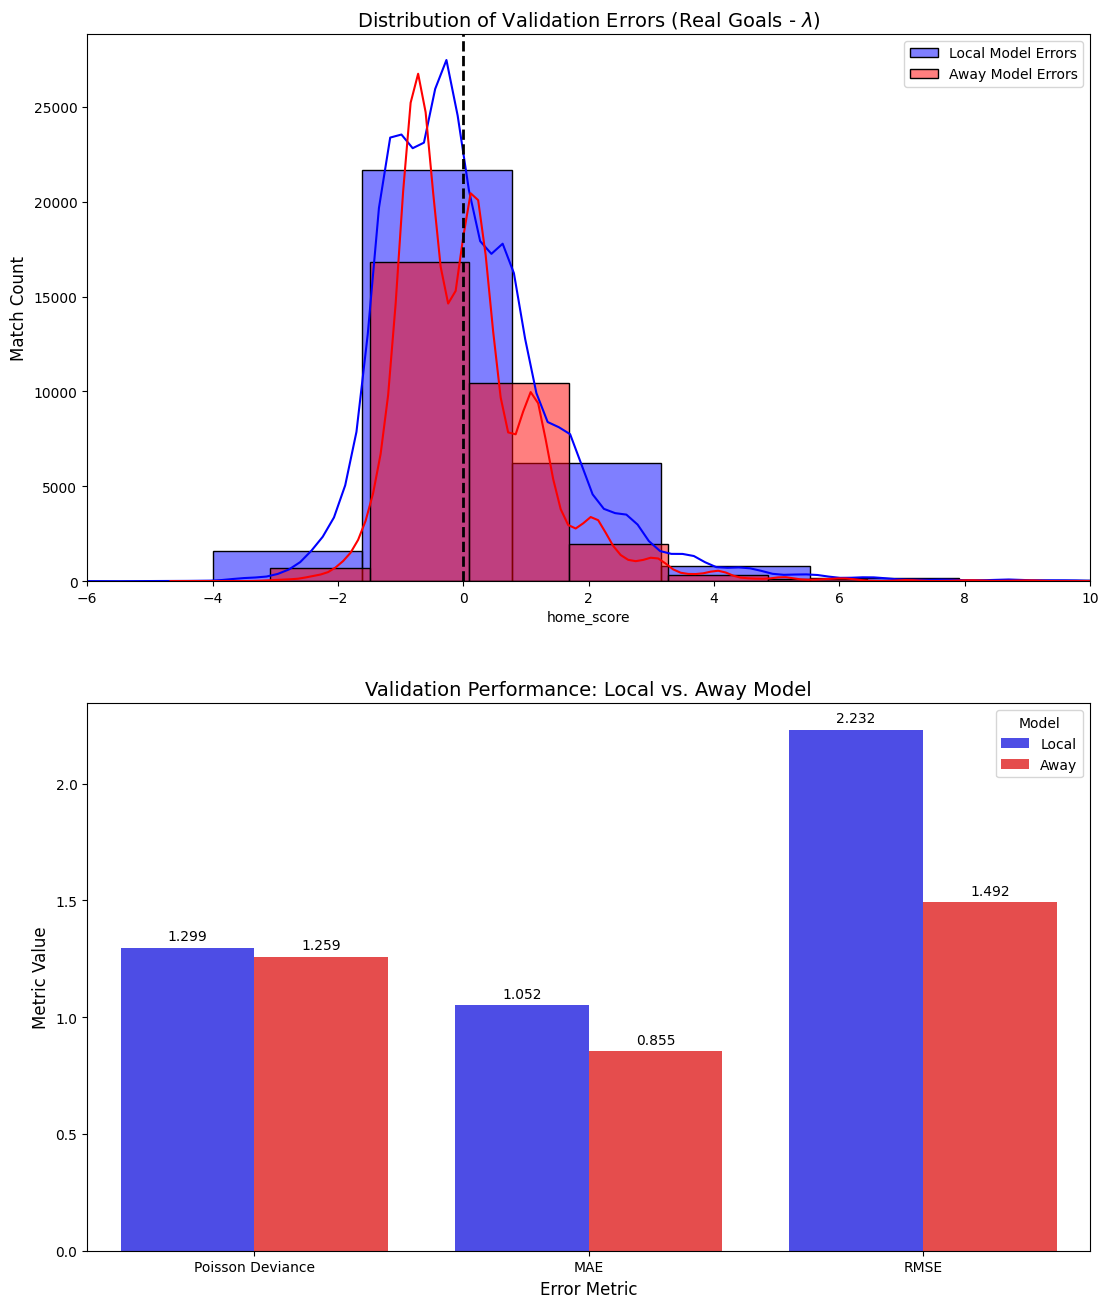

In [8]:
lambda_test_local = model_goals_local.predict(X_test)
lambda_test_away = model_goals_away.predict(X_test)


deviance_local = mean_poisson_deviance(y_test_local, lambda_test_local)
deviance_away = mean_poisson_deviance(y_test_away, lambda_test_away)

mae_local = mean_absolute_error(y_test_local, lambda_test_local)
mae_away = mean_absolute_error(y_test_away, lambda_test_away)

rmse_local = mean_squared_error(y_test_local, lambda_test_local)
rmse_away = mean_squared_error(y_test_away, lambda_test_away)


residue_local = y_test_local - lambda_test_local
residue_away = y_test_away - lambda_test_away

# Prepare metrics dataframe for the bar plot
metrics_data = {
    'Metric': ['Poisson Deviance', 'Poisson Deviance', 'MAE', 'MAE', 'RMSE', 'RMSE'],
    'Model': ['Local', 'Away', 'Local', 'Away', 'Local', 'Away'],
    'Value': [deviance_local, deviance_away, mae_local, mae_away, rmse_local, rmse_away]
}
df_metrics = pd.DataFrame(metrics_data)

# Grid layout: 2 rows, 1 column
fig, axes = plt.subplots(2, 1, figsize=(12, 14))


sns.histplot(residue_local, kde=True, color='blue', alpha=0.5, label='Local Model Errors', ax=axes[0], bins=15)
sns.histplot(residue_away, kde=True, color='red', alpha=0.5, label='Away Model Errors', ax=axes[0], bins=15)
axes[0].axvline(0, color='black', linestyle='--', linewidth=2)
axes[0].set_title('Distribution of Validation Errors (Real Goals - $\lambda$)', fontsize=14)
axes[0].set_ylabel('Match Count', fontsize=12)
axes[0].set_xlim(-6, 10)
axes[0].legend()

sns.barplot(x='Metric', y='Value', hue='Model', data=df_metrics, ax=axes[1], palette=['blue', 'red'], alpha=0.8)
axes[1].set_title('Validation Performance: Local vs. Away Model', fontsize=14)
axes[1].set_xlabel('Error Metric', fontsize=12)
axes[1].set_ylabel('Metric Value', fontsize=12)


for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.3f', padding=3)

plt.tight_layout(pad=4.0)
plt.show()

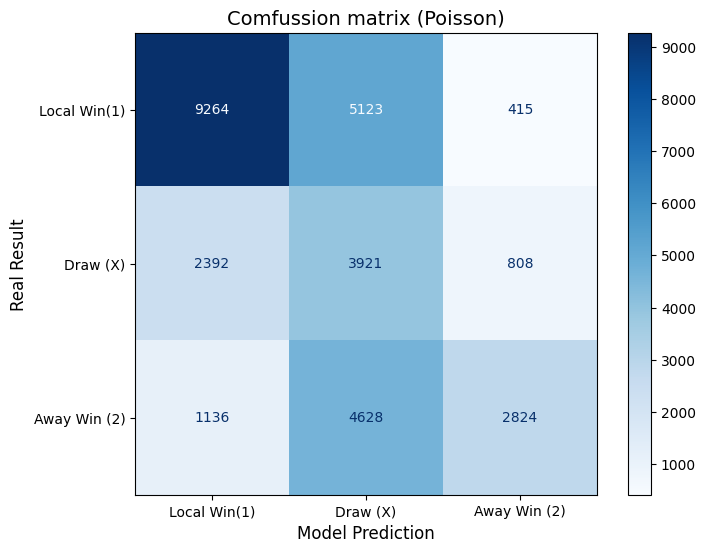

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
result_conditions = [
    y_test_local > y_test_away,  # Gana Local
    y_test_local == y_test_away, # Empate
    y_test_local < y_test_away   # Gana Visitante
]
categories = [1, 0, 2]
real_result = np.select(result_conditions, categories)


pred_home_score = np.round(lambda_test_local)
pred_away_score = np.round(lambda_test_away)

pred_result_conditions = [
    pred_home_score > pred_away_score,
    pred_home_score == pred_away_score,
    pred_home_score < pred_away_score
]
pred_result = np.select(pred_result_conditions, categories)

cm = confusion_matrix(real_result, pred_result, labels=[1, 0, 2])


fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Local Win(1)', 'Draw (X)', 'Away Win (2)'])
disp.plot(cmap='Blues', ax=ax, values_format='d')

plt.title('Comfussion matrix (Poisson)', fontsize=14)
plt.xlabel('Model Prediction', fontsize=12)
plt.ylabel('Real Result', fontsize=12)
plt.show()

In [13]:
# 1. Definir parámetros de la simulación
n_simulations = 10000

# 2. Obtener los lambdas esperados para el conjunto de test
lambdas_local = model_goals_local.predict(X_test)
lambdas_away = model_goals_away.predict(X_test)

# 3. MONTECARLO VECTORIZADO: Generamos una matriz de (Partidos x 10,000 simulaciones)
# Usamos [:, None] para que NumPy propague cada lambda a lo largo de las 10,000 columnas
sim_goals_local = np.random.poisson(lambdas_local[:, None], size=(len(X_test), n_simulations))
sim_goals_away = np.random.poisson(lambdas_away[:, None], size=(len(X_test), n_simulations))

# 4. Calcular la probabilidad real de cada resultado por partido
prob_local = np.mean(sim_goals_local > sim_goals_away, axis=1)
prob_draw  = np.mean(sim_goals_local == sim_goals_away, axis=1)
prob_away  = np.mean(sim_goals_local < sim_goals_away, axis=1)

# 5. Guardar las predicciones finales basadas en la probabilidad más alta
# Índices de la matriz: 0 = Draw, 1 = Local Win, 2 = Away Win
mc_proba_matrix = np.column_stack([prob_draw, prob_local, prob_away])
random_dice = np.random.rand(len(X_test))

# Calculamos la suma acumulada de las probabilidades para el reparto del "dado"
proba_cumsum = np.cumsum(mc_proba_matrix, axis=1)

# Determinamos el resultado según dónde caiga el dado (0=Draw, 1=Local, 2=Away)
mc_predictions = np.sum(random_dice[:, None] > proba_cumsum, axis=1)

# 5. Procesar los resultados reales del test para comparar
real_outcomes = np.where(y_test_local > y_test_away, 1,
                         np.where(y_test_local < y_test_away, 2, 0))

# 6. Procesar los resultados reales del test para poder comparar
real_outcomes = np.where(y_test_local > y_test_away, 1,
                         np.where(y_test_local < y_test_away, 2, 0))

🎯 Monte Carlo Model Accuracy: 47.03%

📋 Classification Report (Monte Carlo):
               precision    recall  f1-score   support

     Draw (0)       0.25      0.24      0.25      7121
Local Win (1)       0.59      0.60      0.60     14802
 Away Win (2)       0.43      0.43      0.43      8588

     accuracy                           0.47     30511
    macro avg       0.42      0.42      0.42     30511
 weighted avg       0.47      0.47      0.47     30511



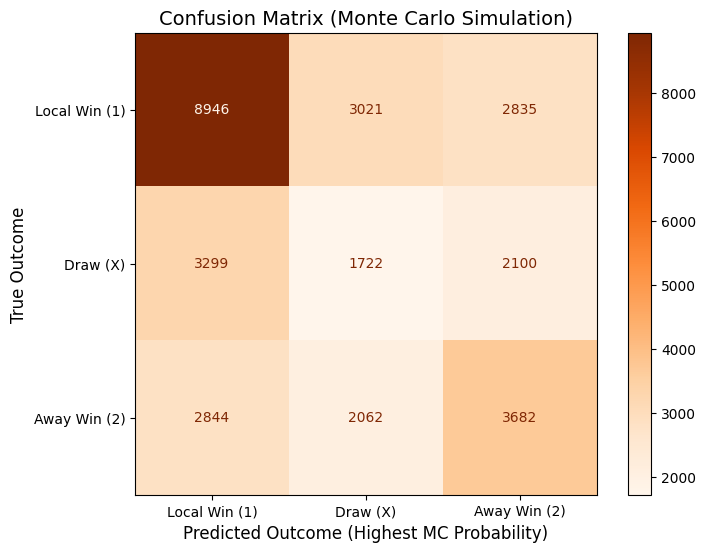

In [14]:
from sklearn.metrics import accuracy_score, classification_report

# 1. Imprimir reporte estadístico en consola
print(f"🎯 Monte Carlo Model Accuracy: {accuracy_score(real_outcomes, mc_predictions) * 100:.2f}%")
print("\n📋 Classification Report (Monte Carlo):")
print(classification_report(real_outcomes, mc_predictions, target_names=['Draw (0)', 'Local Win (1)', 'Away Win (2)']))

# 2. Calcular la nueva Matriz de Confusión
# Usamos el orden [1, 0, 2] para mantener la misma estructura que tu gráfica anterior
cm_mc = confusion_matrix(real_outcomes, mc_predictions, labels=[1, 0, 2])

# 3. Graficar de forma elegante
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_mc, display_labels=['Local Win (1)', 'Draw (X)', 'Away Win (2)'])

# Usamos un color distinto (Naranja) para diferenciarla visualmente de la anterior de redondeo
disp.plot(cmap='Oranges', ax=ax, values_format='d')

plt.title('Confusion Matrix (Monte Carlo Simulation)', fontsize=14)
plt.xlabel('Predicted Outcome (Highest MC Probability)', fontsize=12)
plt.ylabel('True Outcome', fontsize=12)
plt.show()